<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
import os
PATH = ''

Для Colab

In [2]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: # sound_classification_dataset.zip
usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: # train.csv
usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: # valid.csv

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [3]:
!unzip /content/sound_classification_dataset.zip

"unzip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


Локально

In [4]:
# PATH = 'content/'

In [5]:
# import os

# # os.makedirs("data", exist_ok=True)

# # # Скачиваем файлы в папку data
# # !gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO -O content/sound_classification_dataset.zip
# # !gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT -O content/train.csv
# # !gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 -O content/valid.csv
# # !gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks -O content/test.csv

In [6]:
# !unzip -q data/sound_classification_dataset.zip -d content/

### Install

In [ ]:
!pip uninstall -y torchaudio torch librosa
!pip install torch torchaudio
!pip install librosa audiomentations

Found existing installation: torchaudio 2.11.0.dev20260328+cu128
Uninstalling torchaudio-2.11.0.dev20260328+cu128:
  Successfully uninstalled torchaudio-2.11.0.dev20260328+cu128
Found existing installation: torch 2.12.0.dev20260328+cu128
Uninstalling torch-2.12.0.dev20260328+cu128:
  Successfully uninstalled torch-2.12.0.dev20260328+cu128
Found existing installation: librosa 0.11.0
Uninstalling librosa-0.11.0:
  Successfully uninstalled librosa-0.11.0
^C
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

    Uninstalling numpy-1.26.4:

   ------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.26.0.dev20260328+cu128 requires torch, which is not installed.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
karateclub 1.2.1 requires decorator==4.4.2, but you have decorator 5.1.1 which is incompatible.


  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
    --------------------------------------- 1.8/114.6 MB 6.3 MB/s eta 0:00:18
   - -------------------------------------- 2.9/114.6 MB 6.0 MB/s eta 0:00:19
   - -------------------------------------- 4.2/114.6 MB 6.1 MB/s eta 0:00:18
   - -------------------------------------- 5.5/114.6 MB 6.2 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/114.6 MB 6.1 MB/s eta 0:00:18
   -- ------------------------------------- 8.1/114.6 MB 6.1 MB/s eta 0:00:18
   --- ------------------------------------ 9.4/114.6 MB 6.2 MB/s eta 0:00:17
   --- ------------------------------------ 10.7/114.6 MB 6.3 MB/s eta 0:00:17
   ---- ----------------------------------- 12.3/114.6 MB 6.4 MB/s eta 0:00:17
   ---- ----------------------------------- 13.6/114.6 MB 6.4 MB/s eta 0:00:16
   ----- -

### Imports and Seeds

In [ ]:
import os
import random
import numpy as np
import torch
import sys

def set_seed(seed=42):
    # Фиксирует все источники случайности
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [ ]:
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from IPython.display import clear_output
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch, Shift, Gain

In [ ]:
# # Добавляем FFmpeg в PATH для текущей сессии

# ffmpeg_bin = r'C:\ffmpeg\bin'
# if os.path.exists(ffmpeg_bin):
#     os.environ['PATH'] = ffmpeg_bin + os.pathsep + os.environ['PATH']
#     print(f'FFmpeg path added: {ffmpeg_bin}')

#     !ffmpeg -version
# else:
#     print(f'FFmpeg not found at {ffmpeg_bin}')

FFmpeg path added: C:\ffmpeg\bin
ffmpeg version N-123586-g711b1a52bd-20260322 Copyright (c) 2000-2026 the FFmpeg developers
built with gcc 15.2.0 (crosstool-NG 1.28.0.23_185f348)
configuration: --prefix=/ffbuild/prefix --pkg-config-flags=--static --pkg-config=pkg-config --cross-prefix=x86_64-w64-mingw32- --arch=x86_64 --target-os=mingw32 --enable-gpl --enable-version3 --disable-debug --enable-shared --disable-static --disable-w32threads --enable-pthreads --enable-iconv --enable-zlib --enable-libxml2 --enable-libvmaf --enable-fontconfig --enable-libharfbuzz --enable-libfreetype --enable-libfribidi --enable-vulkan --enable-libshaderc --enable-libvorbis --disable-libxcb --disable-xlib --disable-libpulse --enable-opencl --enable-gmp --enable-lzma --enable-liblcevc-dec --enable-amf --enable-libaom --enable-libaribb24 --enable-avisynth --enable-chromaprint --enable-libdav1d --enable-libdavs2 --enable-libdvdread --enable-libdvdnav --disable-libfdk-aac --enable-ffnvcodec --enable-cuda-llvm --e

### Load Dataset

In [ ]:
train_df = pd.read_csv(PATH + 'train.csv')
valid_df = pd.read_csv(PATH + 'valid.csv')
test_df = pd.read_csv(PATH + 'test.csv')

In [ ]:
train_df.sample(3)

,filename,category
44,2-114280-A-0.wav,dog
47,2-117271-A-0.wav,dog
4,1-211527-A-20.wav,crying_baby


In [ ]:
valid_df.sample(3)

,filename,category
17,4-181035-A-38.wav,clock_tick
18,4-181286-A-10.wav,rain
1,4-156844-A-21.wav,sneezing


In [ ]:
test_df.sample(3)

,filename
23,5-208030-A-0.wav
36,5-221593-A-21.wav
13,5-198411-E-20.wav


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [ ]:
class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, df, audio_dir=f'/content/content/sound_classification_dataset',
                 target_length_sec=2.0, sample_rate=16000, 
                 do_augmentation=False, has_labels=True):

        self.df = df
        self.audio_dir = audio_dir                                  # Путь к директории с аудиофайлами.
        self.target_length = int(target_length_sec * sample_rate)   # Целевая длина аудио
        self.sample_rate = sample_rate                              # Целевая частота дискретизации
        self.do_augmentation = do_augmentation                      # Нужна ли аугментация (трейн)
        self.has_labels = has_labels                                # Наличие меток (трейн, валидация)
        
        # Словарь для преобразования имени класса в индекс
        if has_labels:
            self.classes = sorted(df['category'].unique())
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        else:
            self.classes = None
            self.class_to_idx = None

        # Список аугментаций
        self.augmentations = Compose([
            # Добавление шума
            AddGaussianNoise(
                min_amplitude=0.001,
                max_amplitude=0.01,
                p=0.5
            ),
            # Изменение высоты тона
            PitchShift(
                min_semitones=-4,
                max_semitones=4,
                p=0.5
            ),
            # Изменение скорости
            TimeStretch(
                min_rate=0.8,
                max_rate=1.25,
                p=0.5
            ),
            # Сдвиг во времени
            Shift(
                min_shift=-0.2,
                max_shift=0.2,
                p=0.5,
                rollover=True
            ),
            # Изменение громкости
            Gain(min_gain_db=-12, 
                 max_gain_db=6, 
                 p=0.5
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # 1. Get the file path and label
        filename = self.df.iloc[index]['filename']
        audio_file_path = os.path.join(self.audio_dir, filename)

        # Получение метки и преобразование в индекс
        if self.has_labels:
            label = self.class_to_idx[self.df.iloc[index]['category']] 
        else:
            label = -1

        # 2. LOAD: Load the raw audio file
        audio_array, sample_rate = librosa.load(audio_file_path, sr=None) # mono=True
        signal = torch.from_numpy(audio_array).float()

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = signal.unsqueeze(0)                    # размерность канала (1, samples)
        signal = self._resample(signal, sample_rate)    # ресэмплинг к целевой частоте
        signal = self._stereo_to_mono(signal)           # преобразование в моно сигнал
        signal = self._cut_or_pad(signal)               # приведение к фиксированной длине (обрезка или дополнение нулями)

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        signal = signal.squeeze(0)                      # убираем размерность канала
        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr != self.sample_rate:
            resampler = T.Resample(orig_freq=original_sr, new_freq=self.sample_rate)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        current_len = signal.shape[1]
        if current_len > self.target_length:

            if self.do_augmentation:
                start = torch.randint(0, current_len - self.target_length, (1,)).item()
            else:
                start = 0
            signal = signal[:, start:start + self.target_length]
        elif current_len < self.target_length:
            padding = self.target_length - current_len
            signal = torch.nn.functional.pad(signal, (0, padding))
        return signal

    def _augmentation(self, signal):
        signal_np = signal.squeeze(0).cpu().numpy()                                 # из тензора в numpy-массив
        augmented_np = self.augmentations(signal_np, sample_rate=self.sample_rate)  # применение аугменации
        augmented = torch.from_numpy(augmented_np).float().unsqueeze(0)             # из numpy-массива в тензор
        augmented = torch.clamp(augmented, -1.0, 1.0)                               # устранение выбросов
        
        return augmented

In [ ]:
train_dataset = SimpleAudioDataset(train_df, do_augmentation=True, has_labels=True)
valid_dataset = SimpleAudioDataset(valid_df, do_augmentation=False, has_labels=True)
test_dataset = SimpleAudioDataset(test_df, do_augmentation=False, has_labels=False)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [ ]:
import torch.nn as nn

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, input_length_sec=2.0, sample_rate=16000, num_classes=5):
        super().__init__()
        self.input_length = int(input_length_sec * sample_rate)
        
        # Сверточные блоки
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=80, stride=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )

        self.conv5 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=3),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )
        
        # Вычисление размера вектора признаков
        self.fc_input_size = self._compute_fc_input_size()
        
        # Полносвязная часть
        self.fc = nn.Sequential(
            nn.Linear(self.fc_input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    # Вычисление размера вектора признаков (для входа полносвязнаого слоя)
    def _compute_fc_input_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, self.input_length)
            x = self.conv1(x)
            x = self.conv2(x)
            x = self.conv3(x)
            x = self.conv4(x)
            x = self.conv5(x)
            return x.view(1, -1).size(1)
    
    def forward(self, x):
        x = x.unsqueeze(1)          # (batch, 1, sample_length)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = x.view(x.size(0), -1)   # выпрямление тензора
        x = self.fc(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [ ]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

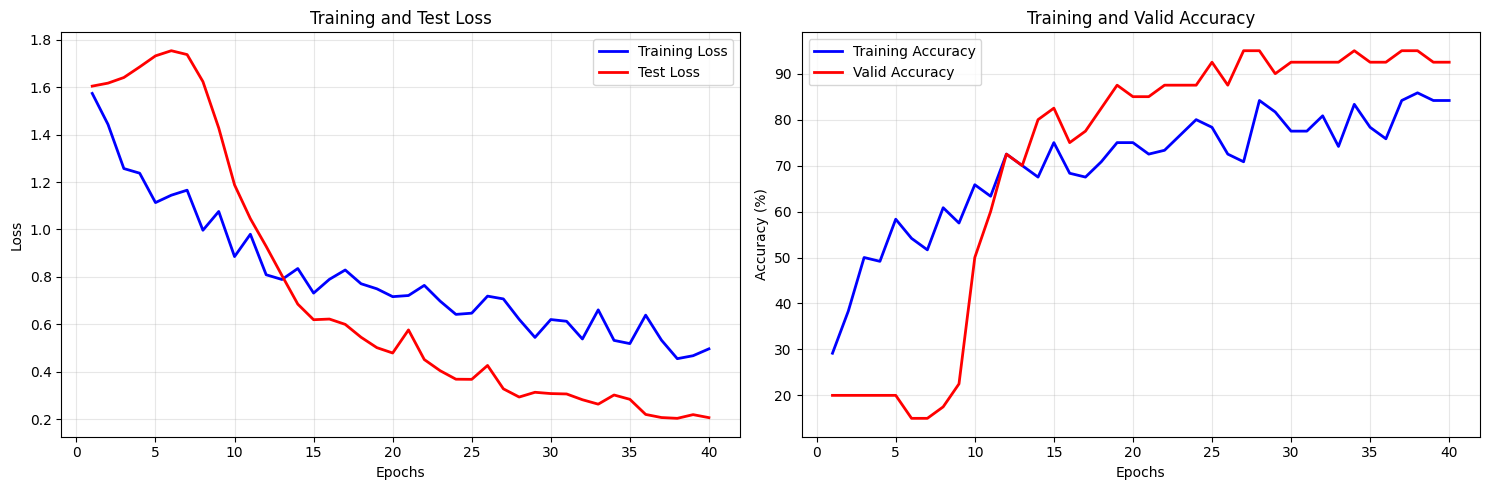

In [ ]:
# Initialize datasets & dataloaders
train_data = train_dataset
valid_data = valid_dataset

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel().to(device)
criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # 0.85
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.005) # 0.85

# Списки для хранения метрик
train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 40
for epoch in range(n_epochs):

    # Train
    model.train()
    train_loss_epoch = 0.0
    train_correct = 0
    train_total = 0

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)

        # Backward pass
        optimizer.zero_grad()  # Обнуляем предыдущие градиенты
        train_loss.backward()  # Вычисляем новые градиенты

        optimizer.step()

        # Сбор статистик
        train_loss_epoch += train_loss.item()
        train_correct += (predictions.argmax(1) == labels).sum().item()
        train_total += labels.size(0)


    # Evaluation
    model.eval()
    valid_loss_epoch = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():   # отключение вычисления градиентов (экономия памяти)
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            valid_loss_epoch += valid_loss.item()
            valid_correct += (predictions.argmax(1) == labels).sum().item()
            valid_total += labels.size(0)

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = train_loss_epoch / len(train_loader)
    epoch_train_acc = 100.0 * train_correct / train_total

    epoch_valid_loss = valid_loss_epoch / len(valid_loader)
    epoch_valid_acc = 100.0 * valid_correct / valid_total

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

In [ ]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  84.16666666666667
Valid Accuracy =  92.5


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cpu
ESC-50 Audio Classification Demo!


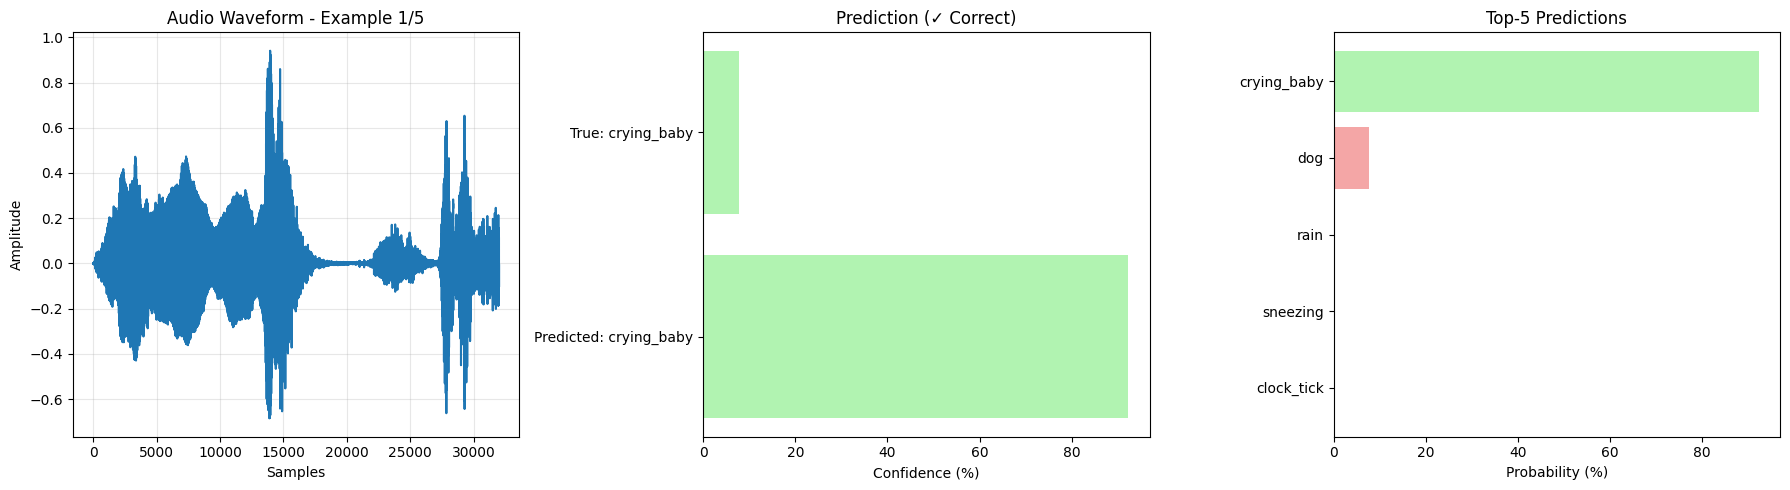

Playing: crying_baby


Prediction: crying_baby (92.33%)
True label: crying_baby
Correct: True


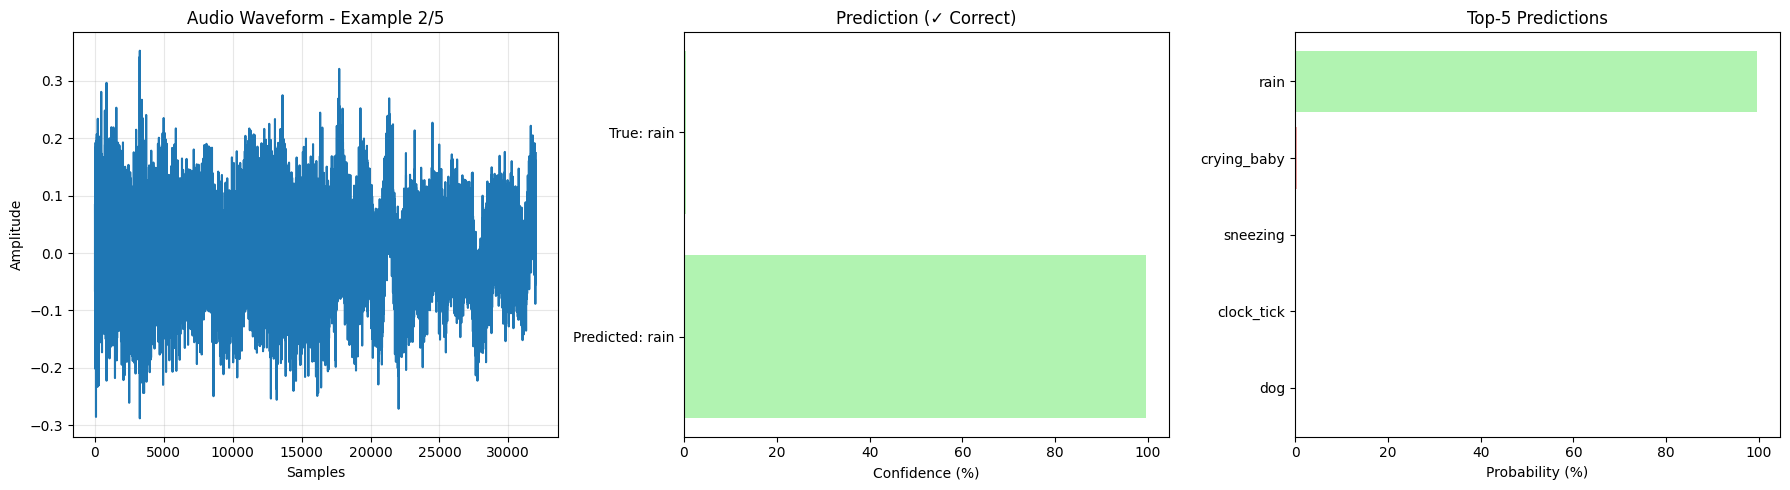

Playing: rain


Prediction: rain (99.52%)
True label: rain
Correct: True


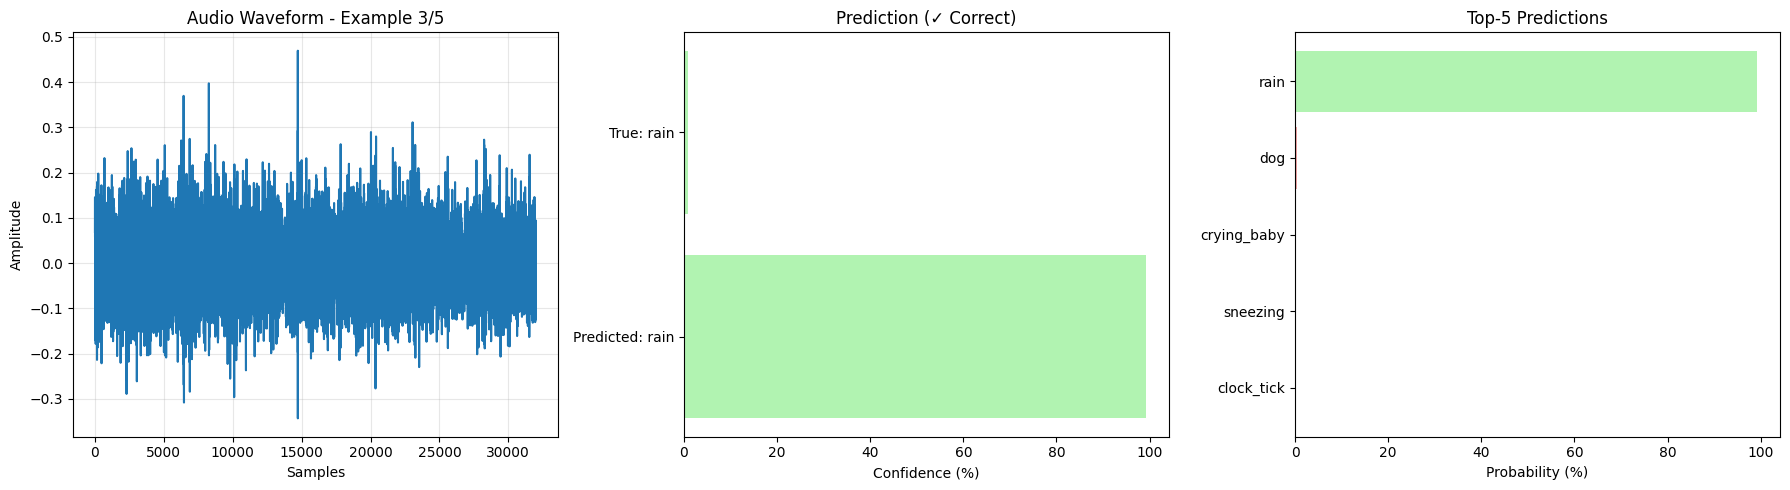

Playing: rain


Prediction: rain (99.19%)
True label: rain
Correct: True


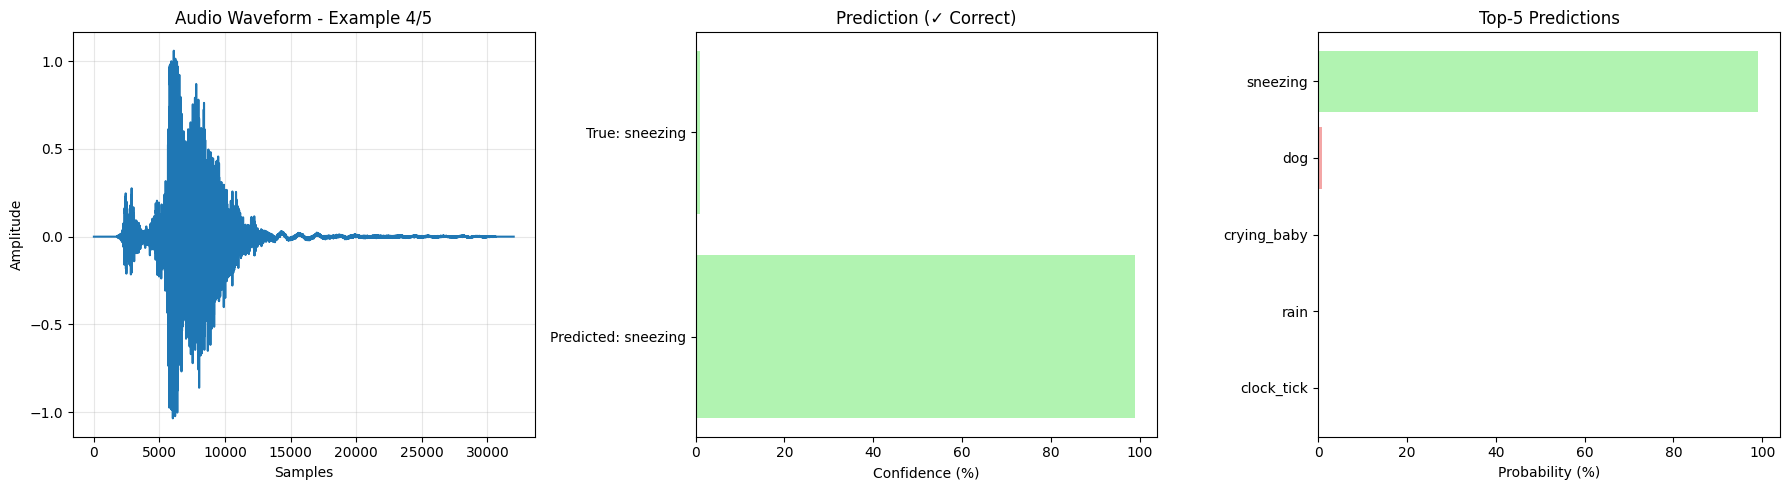

Playing: sneezing


Prediction: sneezing (99.06%)
True label: sneezing
Correct: True


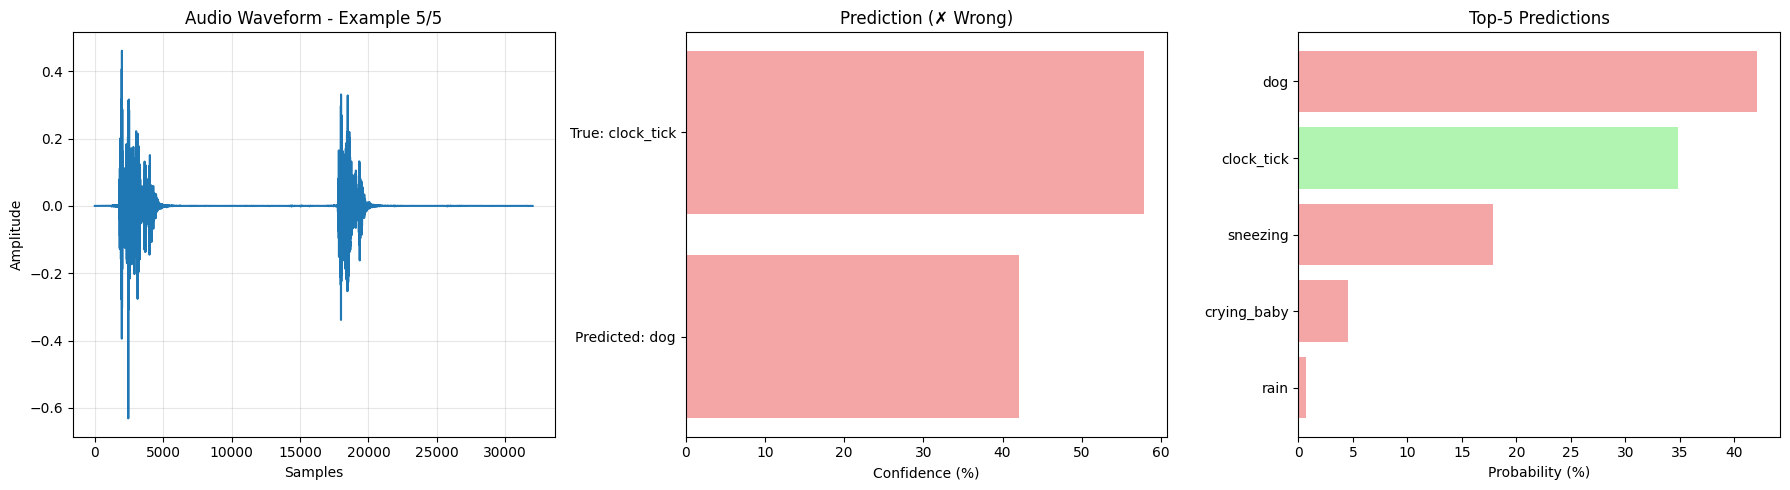

Playing: clock_tick


Prediction: dog (42.10%)
True label: clock_tick
Correct: False
ESC-50 Test Set Evaluation (Fold 5):
Correct: 37/40
Accuracy: 92.50%


In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
model.eval()
y_test_pred = []
with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        y_test_pred.extend(predicted.cpu().numpy())

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# Индексы предсказаний в имена классов
y_test_pred_classes = [idx_to_class[idx] for idx in y_test_pred]

In [ ]:
# Создаем submission файл с правильными названиями классов
submission_name = 'submission'

submission = pd.read_csv(PATH + 'test.csv')
submission['category'] = y_test_pred_classes
submission.to_csv(f'{submission_name}.csv', index=False)

# Проверим несколько строк submission

submission_view = pd.read_csv(f'{submission_name}.csv')

print(submission_view.head())

            filename     category
0  5-151085-A-20.wav  crying_baby
1  5-181766-A-10.wav         rain
2  5-187979-A-21.wav     sneezing
3  5-188655-A-10.wav         rain
4  5-193339-A-10.wav         rain


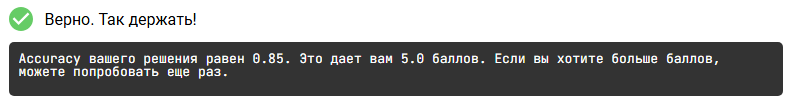

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

1) Для прослеживания изменений и воспроизводимости результатов зафиксировал источники случайности.
2) В классе SimpleAudioDataset использовал базовые преобразования.
3) В классе SoundClassificatonModel реализовал архитектуру с 3 сверточными блоками (Conv1D + BatchNorm + ReLU + MaxPool) и полносвязными слоями (изначально без Dropout)
4) В качестве оптимизатора выбрал Adam, потому что этот оптимизатор хорошо работает без дополнительной настройки параметров ('из коробки').
5) Тестировал размеры батча 32 и 64. Размер батча 32 оказался стабильней.
6) Для повышение обобщающей способности модели добавил аугментации. Подобрал парамеры таким образом, чтобы классы звуков оставались разсличимы. <br>
Точность на валидации заметно подросла.
7) Увеличил количество сверточных слоев с 3 до 4 и, в итоге, до 5 (соответсвенно и конечную ширину слоев), что привело к увеличению точности модели. <br>
Добавил Dropout для уменьшения переобученности.
8) С оптимизатором Adam кривые обучения для Трейна и Валидации значительно разнились. <br>
Перешел на AdamW, настроил learning_rate и weight_decay. Добился более плавной сходимости, уменьшения переобученности и улучшения точности модели.
9) Увелиичивал количество эпох с 20 до 50. Остановился на 40, так как кривая точности после 40 эпохи изменяется незначительно, но появляется переобученность. <br>
<br>
Итог: <br>
Значительное улучшение точности предсказаний внесла аугментация. Также хорошо повысило точность уменьшение learning_rate. <br>
Переобченность снизилась за счет долбавления аугментации, Dropout и регуляризации в AdamW. <br>
<br>


Возможно, для улучшения точности имеет смысл подобрать оптимальные параметры через optuna и выбрать другие разновидностьи Adam (или же, вовсе, использовать ансамбли моделей).